# Analysis of Book Ratings in the Library Collection
**Author**: Vuk

## Goal:

In this notebook, we aim to explore the patterns and relationships behind how books are rated within a punlic library's collection. By analyzing the distribution and correlation of book ratings, we can better understand what drives reader satisfaction and which sections of the library hoild the highset-rated content.

### Objectives:
1. **Understand the overall distribution of book ratings** using histograms and KDE curves.
2. **Compare the rating destribution across different library sections** using boxplots.
3. **Identify correlation** between ratings and other book attributes (e.g., page count, number of ratings, borrowings) using heatmap.
4. **Visualize the strongest correlations** using scatter plots and regression lines.

This analysis can help librarians curators, and datra enthusiasts indetify trends in the book quality and reader preferences across genres and formats.

## Step 1: Import required libraries
We are going to use Pandas to load the data, and Matplotlib and Seaborn to create the charts.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the dataset
We will use a dataset containing information about books:

catalog_position,title,author,year_published,genre,section,total_copies,times_borrowed,last_borrowed_date,rating,ratings_count,price,language,page_count,dimensions_width,dimensions_thickness,dimensions_height,catalog_shelf,catalog_row,catalog_row_number


In [21]:
df = pd.read_csv("books.csv")

## Step 3: Shoe some sample data 
Show first 5 rows

In [22]:
df.head()

,catalog_position,title,author,year_published,genre,section,total_copies,times_borrowed,last_borrowed_date,rating,ratings_count,price,language,page_count,dimensions_width,dimensions_thickness,dimensions_height,catalog_shelf,catalog_row,catalog_row_number
0,A1-B1-0001,Enormous Room,E. E. Cummings,1949.0,Drama,Fiction,5.0,3.0,1/6/2025,3.77,2.0,14.66,en,249.0,4.98,0.60,7.97,A1,B1,1
1,A1-B1-0002,Plutarchi Vitae parallelae,Plutarch,1478.0,Biography & Autobiography,History,4.0,1.0,3/19/2024,NaN,NaN,9.99,en,241.0,5.74,1.12,8.08,A1,B1,2
2,A1-B1-0003,The water-babies,Charles Kingsley,1863.0,Fantasy,Children,6.0,6.0,6/5/2024,3.66,6.0,13.89,en,228.0,7.70,0.70,5.10,A1,B1,3
3,A1-B1-0004,Kipps,H. G. Wells,1900.0,Comedy,Fiction,4.0,5.0,11/6/2024,3.83,4.0,370.00,en,386.0,5.08,0.98,7.80,A1,B1,4
4,A1-B1-0005,Man and Superman,George Bernard Shaw,1903.0,Drama,Fiction,5.0,2.0,1/16/2025,3.84,2.0,10.99,en,220.0,5.08,1.22,7.80,A1,B1,5


## Step 4: Histogram and KDE analysis: The overall distribution of books ratings in the library collection

Understanding how ratings are distributed can help us identify common patterns, such as:
- Whether most books receive average or high ratings,
- If there are books with exceptionally low or high ratings,
- Whether the distribution is skewed or symetric.

We will use histogram to visualize how many books fall into each rating range, and overaly a KDE (Kernel Density Estimate) curve to better the shape of the distribution.

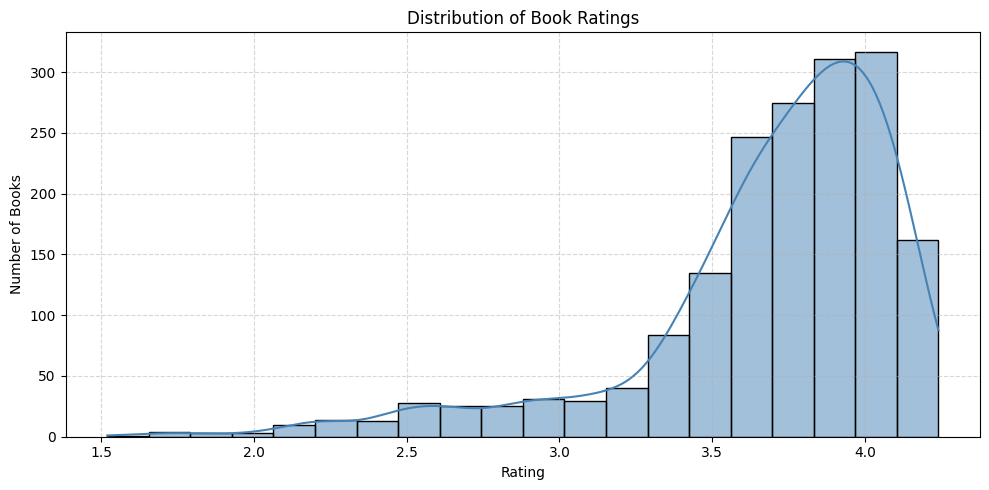

In [23]:
plt.figure(figsize=(10, 5))
sns.histplot(df["rating"], bins=20, kde=True, color="steelblue", edgecolor="black")
 
plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Step 5: Boxplot Analysis: Distribution of Book Ratings by Library Section

After examining the overall distribution of book ratings, we now want to explore how these ratings very across diffrent sections of the library(e.g., Fisction, Science, History, etc.).

For this purpose, we will use a **boxplot**, which allows us to:
- Compare the central tendency (median rating) across sections,
- Observe the spread and variability of ratings within each section,
- Indetify potentional outliers - execptionaly high or low rated books.

This Visualization helps us answer questions such as:
- Which section tend to have the highest-rated books?
- Are there sections with more cinsistent ratings?
- Do any sections contain books that are significantly over- or under-rated?

Let's take a look at the rating distribution by section.

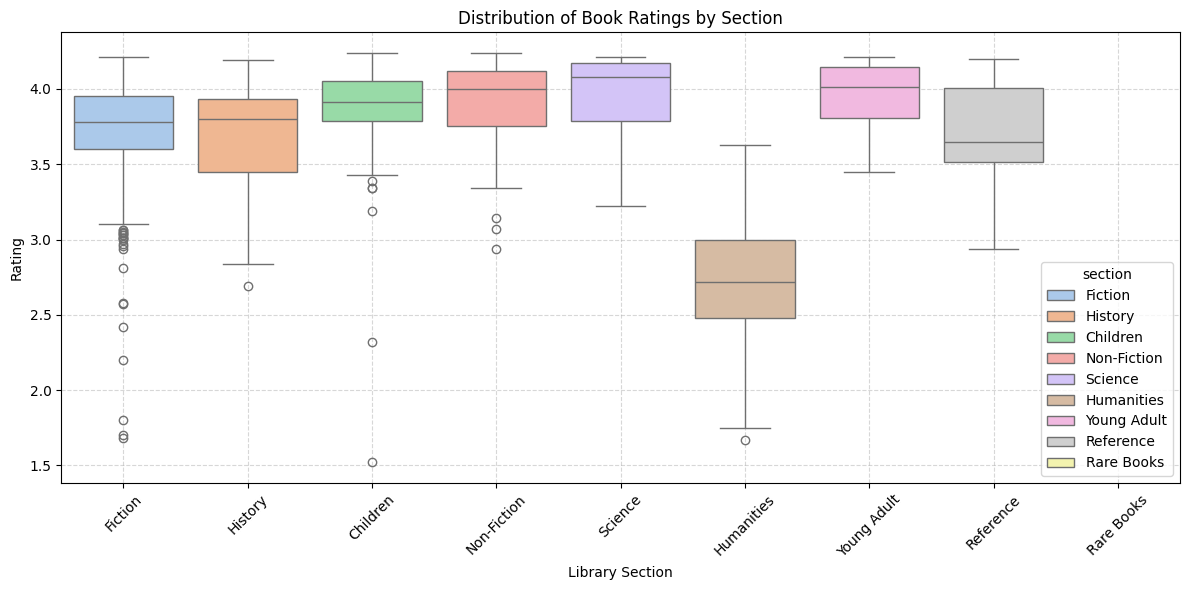

In [24]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="section", y="rating", hue="section", palette="pastel")
 
plt.title("Distribution of Book Ratings by Section")
plt.xlabel("Library Section")
plt.ylabel("Rating")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Step 6: Coerrlation Heatmap: Understanding Relationships Between Ratings and Other Features

To gain a Broader perspective on how ratings realte to other numerical attributes in the dataset, we will generate a **correlation matrix** and visualize it using a **heatmap**.

This type of visualization help us to:
- Indentify which features are most strongly correlated with `rating`, 
- Detect weak or no relationships,
- Understand how features like `page_count`, `times_borrowed`, `rating_count` and `total_copies` interact with one another.

The values in the heatmap range from **-1 (strong negative ccorrelation)** to **+1 (strong positive correlation)**.
Values jclose to 0 indicate little or no linear correlation.

This overview help us select the most relevant features for more detailed scattter plot analysis in the next step.

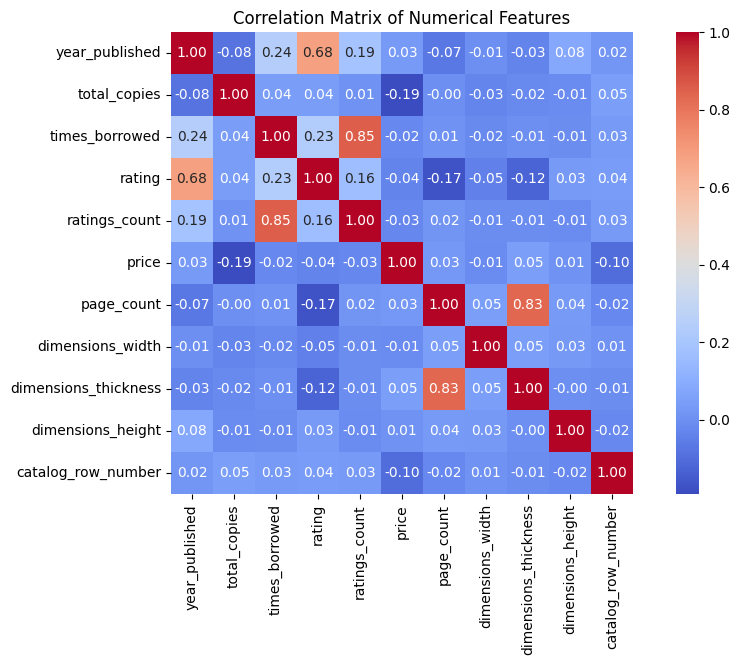

In [25]:
numeric_df = df.select_dtypes(include="number")
 
correlation_matrix = numeric_df.corr()
 
plt.figure(figsize=(11, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
 
plt.title("Correlation Matrix of Numerical Features")
plt.show()

## Step 7: Scatter Plot Analysis: Exploring Correlation with Ratings

In this final part of the analysis, we will use scatter plots to explore how diffrent book-related features correlate with their average ratings. By plotting these variables against ratings and adding trend lines, we can vasially detect:

- Positive or negative relationships,
- Non-linear patterns,
- Potential outliers or clusters.

We selected two features that axhibited the strongest correlations with ratings:

- `year_published`: Are newer books rated more highly?
- `page_count`: Is there any relationships betwwn the number of pages and how readers rate books?

These scatter plots help uncover meangful insights that may not be visible through summary statistics alone.

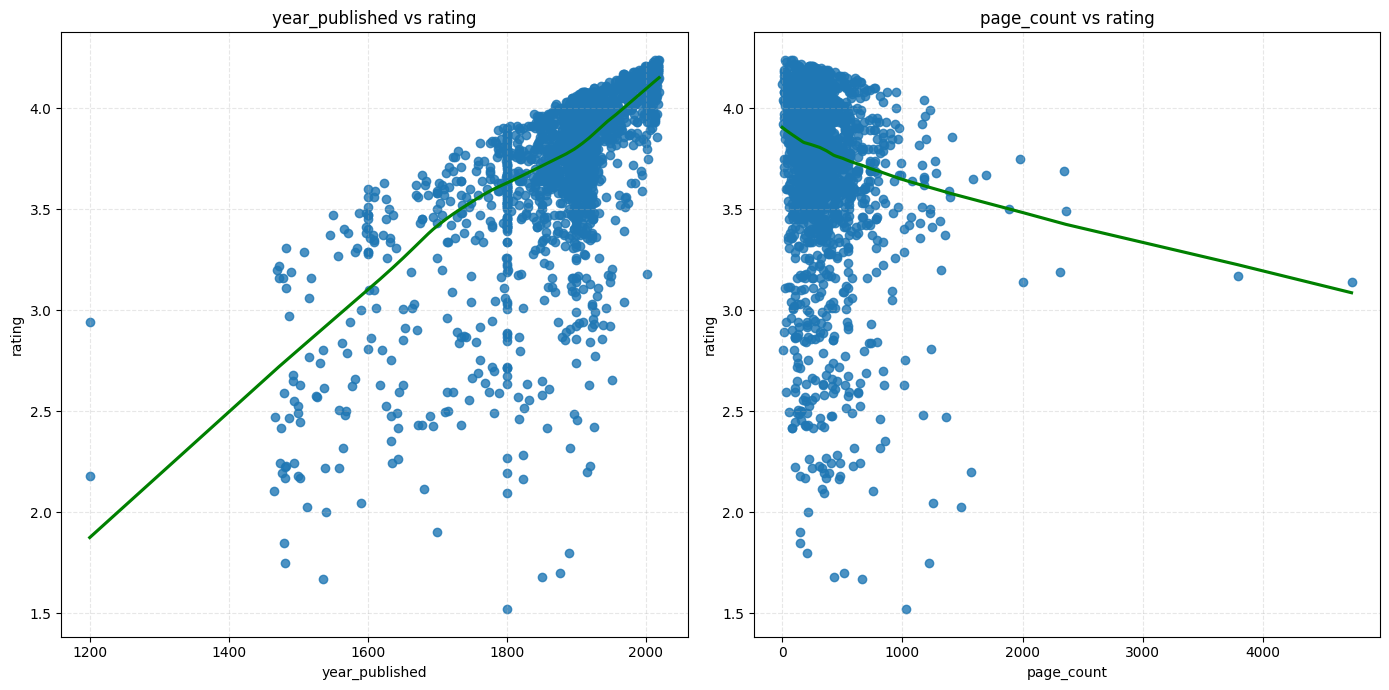

In [26]:
features = ["year_published", "page_count"]
 
fig, axs = plt.subplots(1, 2, figsize=(14, 7))
 
def plot_scatter_with_trend(ax, x, y="rating"):
    sns.regplot(data=df, x=x, y=y, ax=ax, line_kws={"color": "green"}, lowess=True)
    ax.set_title(f"{x} vs {y}")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.grid(True, linestyle="--", alpha=0.3)
 
for i, feature in enumerate(features):
    plot_scatter_with_trend(axs[i], feature)
 
plt.tight_layout()
plt.show()

# Conclusion and Summary of the Analysis

## Distribution of the number of units sold
- Most of the products are sold in the range of **600-1300 pieces**, which represents the main part of the market.
- There are **outliers** on the upper side (eg *Xbox Series X (White) - 2352 pieces*, *Saturn - 1797 pieces*, *Pico - 1725 pieces*) that deviate significantly from the average.
- On the lower side, products like *Forerunner 245 (Red) – 356 units* or *Watch Series 7 (Gray) – 419 units* show weak sales.

## Analysis by category
- **Gaming Consoles**, **Tablets** and **Shoes** have the highest total number of units sold.
- The boxplot shows that **Gaming Consoles** are most prone to extremes - some models sell extremely well, while others remain average.
- Categories like **Watches** and **Furniture** have a wider range of values, meaning that sales vary significantly between items within the same category.

## Correlation of numerical properties
- **Price ↔ Revenue** → very strong positive correlation (revenue depends on price × quantity).
- **Quantity_sold ↔ Revenue** → strong positive correlation, number of units sold directly affects revenue.
- **Rating ↔ Num_of_ratings** → moderate correlation, products with more ratings have a more stable rating.

## Scatter plot analysis
- **Num_of_ratings vs Quantity_sold** → products with more ratings generally have higher sales; the trend line shows a positive relationship.
- **Price vs Quantity_sold** → complex relationship: cheaper products are sold en masse, while more expensive ones have variable results (some luxury items successful, others poorly).
- Scatter plots visually confirm the correlations we observed earlier.

---

## Summary
- **The main mass of sales** takes place in the range of 600-1300 pieces per product.
- **Gaming consoles and tablets** are the most dominant categories, with pronounced outliers generating huge sales.
- **Price and number of units sold** are key revenue factors, while rating has a secondary but significant impact.
- **Extremes** (best-selling and least-selling products) give a signal for inventory management: the most sought-after items should be additionally supported, while the weak ones should be reconsidered or promoted.

---